# 01 — Learning Theory, PAC, Polynomial Bases, and Generalization

A conceptual and computational bridge from classical machine learning to representation learning.

## Learning objectives

By the end of this notebook, you should be able to:

- distinguish **computational learnability** from **statistical learnability**;
- explain hypothesis classes, empirical risk, true risk, and the generalization gap;
- state the idea behind **PAC learning** and finite-class sample-complexity bounds;
- understand polynomial regression as a linear model in a nonlinear feature space;
- construct a **complete polynomial basis** in one or several variables;
- connect basis functions, spans, function spaces, projection, and approximation;
- diagnose underfitting and overfitting using learning curves.

This notebook emphasizes understanding rather than proof-level rigor. Optional derivations are marked clearly.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)

## 1. The formal supervised-learning setup

Assume examples are drawn from an unknown distribution $\mathcal{D}$ over input-output pairs $(X,Y)$.

- A **hypothesis** $h$ is a candidate prediction rule.
- A **hypothesis class** $\mathcal{H}$ is the set of rules the learner is allowed to choose from.
- A **loss function** $\ell(h(x),y)$ measures prediction error.

The **population risk** or **true risk** is

$$
R(h)=\mathbb{E}_{(X,Y)\sim\mathcal{D}}[\ell(h(X),Y)].
$$

Because $\mathcal{D}$ is unknown, training uses the **empirical risk** on a sample $S=\{(x_i,y_i)\}_{i=1}^n$:

$$
\widehat R_S(h)=\frac{1}{n}\sum_{i=1}^{n}\ell(h(x_i),y_i).
$$

**Empirical Risk Minimization (ERM)** chooses

$$
\widehat h\in \arg\min_{h\in\mathcal H}\widehat R_S(h).
$$

The central question is not only whether $\widehat h$ fits the sample, but whether it predicts well on new examples.

### Statistical versus computational questions

These are related but different:

| Question | Main concern |
|---|---|
| **Statistical learnability** | How many examples are needed to generalize? |
| **Computational learnability** | Can an algorithm find a good hypothesis efficiently? |
| **Representational adequacy** | Does the hypothesis class contain a sufficiently good predictor? |

A class may be statistically learnable but computationally hard to optimize. Conversely, an optimization problem may be easy while the chosen class is too weak to represent the target relationship.

## 2. Generalization

The **generalization gap** for a fitted model is

$$
R(h)-\widehat R_S(h).
$$

In practice, the unknown population risk is estimated using validation or test data.

Generalization usually improves when:

- the sample size grows;
- the hypothesis class is controlled;
- regularization is appropriate;
- data leakage is prevented;
- train and deployment distributions are similar.

A model with near-zero training error can still have poor population error. This is overfitting.

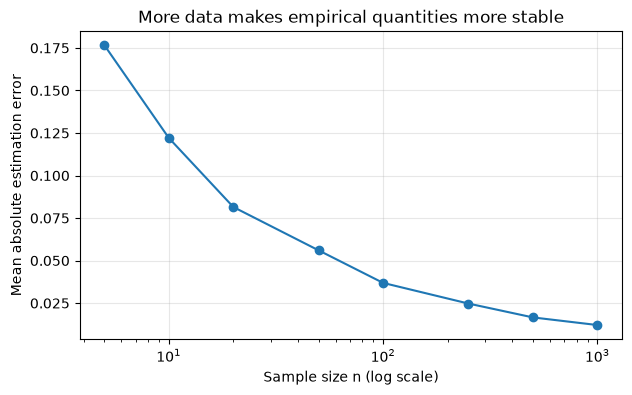

In [4]:
# A small simulation: empirical means concentrate around the true mean.
true_p = 0.35
sample_sizes = np.array([5, 10, 20, 50, 100, 250, 500, 1000])
repetitions = 1000
mean_absolute_errors = []

for n in sample_sizes:
    sample_means = rng.binomial(n=1, p=true_p, size=(repetitions, n)).mean(axis=1)
    mean_absolute_errors.append(np.mean(np.abs(sample_means - true_p)))

plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, mean_absolute_errors, marker='o')
plt.xscale('log')
plt.xlabel('Sample size n (log scale)')
plt.ylabel('Mean absolute estimation error')
plt.title('More data makes empirical quantities more stable')
plt.grid(alpha=0.3)
plt.show()

The plot is an example of **concentration**: as $n$ grows, an empirical estimate becomes less variable. Learning-theory bounds formalize how sample size, confidence, accuracy, and model-class complexity interact.

## 3. PAC learning

**PAC** means **Probably Approximately Correct**.

A learning algorithm is PAC-style successful when, for chosen values $\epsilon>0$ and $\delta>0$, it returns a hypothesis whose error is at most $\epsilon$ above the desired reference error, with probability at least $1-\delta$ over the random training sample.

- $\epsilon$ is the tolerated error or excess error: **approximately correct**.
- $\delta$ is the tolerated failure probability: **probably**.

For a finite hypothesis class in the realizable classification setting, a common bound has the form

$$
n \gtrsim \frac{\log |\mathcal H| + \log(1/\delta)}{\epsilon}.
$$

The exact constants depend on the theorem and assumptions. The important message is:

- larger hypothesis classes require more data;
- demanding smaller error requires more data;
- demanding higher confidence requires more data.

In [6]:
def finite_class_sample_bound(H_size, epsilon, delta):
    """A standard realizable-case sufficient bound: (ln|H| + ln(1/delta))/epsilon."""
    return math.ceil((math.log(H_size) + math.log(1 / delta)) / epsilon)

settings = [
    (100, 0.10, 0.05),
    (1000, 0.10, 0.05),
    (1000, 0.05, 0.05),
    (1000, 0.05, 0.01),
]

for H_size, eps, delta in settings:
    print(f'|H|={H_size:>5}, epsilon={eps:.2f}, delta={delta:.2f} -> n >= {finite_class_sample_bound(H_size, eps, delta)}')

|H|=  100, epsilon=0.10, delta=0.05 -> n >= 77
|H|= 1000, epsilon=0.10, delta=0.05 -> n >= 100
|H|= 1000, epsilon=0.05, delta=0.05 -> n >= 199
|H|= 1000, epsilon=0.05, delta=0.01 -> n >= 231


### Agnostic PAC intuition

The realizable assumption says that some hypothesis in $\mathcal H$ has zero population error. Real data rarely satisfies this exactly.

In the **agnostic** setting, the goal becomes

$$
R(\widehat h) \leq \inf_{h\in\mathcal H}R(h)+\epsilon
$$

with probability at least $1-\delta$.

A typical finite-class sample complexity scales like

$$
n=O\left(\frac{\log |\mathcal H|+\log(1/\delta)}{\epsilon^2}\right).
$$

The $1/\epsilon^2$ dependence reflects the harder noisy setting.

## 4. Infinite classes and capacity

Many useful classes are infinite: all lines, all degree-$d$ polynomials, or all neural networks of a given architecture.

For classification, **VC dimension** measures how rich a hypothesis class is by asking how many points it can shatter—label in every possible way.

Intuition:

- low capacity: stable but may underfit;
- high capacity: expressive but can overfit without enough data or regularization;
- useful learning balances approximation power and estimation reliability.

Capacity is not just the number of possible parameter values. Linear classifiers have real-valued parameters and therefore infinitely many settings, yet finite VC dimension under standard assumptions.

## 5. Polynomial regression is linear in its parameters

A degree-$d$ univariate polynomial model is

$$
\widehat y = \beta_0+\beta_1x+\beta_2x^2+\cdots+\beta_dx^d.
$$

It is nonlinear as a function of $x$, but linear in the coefficients $\beta_j$. Define the feature map

$$
\phi_d(x)=[1,x,x^2,\ldots,x^d]^\top.
$$

Then

$$
\widehat y=\beta^\top\phi_d(x).
$$

This perspective—linear prediction after a feature map—is central to basis expansions, kernels, and neural representations.

In [8]:
# Build a Vandermonde/design matrix manually.
x_small = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
degree = 3
Phi = np.column_stack([x_small ** power for power in range(degree + 1)])
print('Rows correspond to examples; columns correspond to 1, x, x^2, x^3:')
print(Phi)

Rows correspond to examples; columns correspond to 1, x, x^2, x^3:
[[ 1. -2.  4. -8.]
 [ 1. -1.  1. -1.]
 [ 1.  0.  0.  0.]
 [ 1.  1.  1.  1.]
 [ 1.  2.  4.  8.]]


## 6. Complete polynomial bases

For $p$ input variables and total degree at most $d$, the **complete polynomial basis** contains every monomial

$$
x_1^{\alpha_1}x_2^{\alpha_2}\cdots x_p^{\alpha_p}
$$

whose nonnegative exponents satisfy

$$
\alpha_1+\cdots+\alpha_p\leq d.
$$

For two variables and degree 2, the complete basis is

$$
1,\ x_1,\ x_2,\ x_1^2,\ x_1x_2,\ x_2^2.
$$

The number of terms is

$$
\binom{p+d}{d}.
$$

This combinatorial growth is one form of the **curse of dimensionality**.

In [9]:
def complete_exponents(num_variables, max_degree):
    """Return exponent tuples with total degree <= max_degree."""
    return [exp for exp in product(range(max_degree + 1), repeat=num_variables)
            if sum(exp) <= max_degree]

for p, d in [(2, 2), (2, 3), (5, 3), (20, 3)]:
    exponents = complete_exponents(p, d) if p <= 5 else None
    count = math.comb(p + d, d)
    print(f'p={p:>2}, d={d}: {count} basis terms')

print('\nExponents for p=2, d=2:', complete_exponents(2, 2))

p= 2, d=2: 6 basis terms
p= 2, d=3: 10 basis terms
p= 5, d=3: 56 basis terms
p=20, d=3: 1771 basis terms

Exponents for p=2, d=2: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (2, 0)]


In [6]:
# Compare our count with scikit-learn's PolynomialFeatures.
X_demo = np.array([[2.0, 3.0]])
poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X_demo)
print(poly.get_feature_names_out(['x1', 'x2']))
print(X_poly)

['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
[[1. 2. 3. 4. 6. 9.]]


## 7. Function spaces, span, and basis

A **function space** is a set of functions with algebraic structure. For example,

$$
\mathcal P_d=\{\beta_0+\beta_1x+\cdots+\beta_dx^d\}
$$

is the vector space of polynomials of degree at most $d$.

The functions $1,x,\ldots,x^d$ form a basis because:

1. they **span** $\mathcal P_d$—every function in the space is their linear combination;
2. they are linearly independent.

With an inner product such as

$$
\langle f,g\rangle=\int_a^b f(x)g(x)w(x)\,dx,
$$

we can discuss orthogonality, norms, and projections. Least squares is a projection of observed targets onto the span of chosen basis functions.

### Monomial versus orthogonal bases

The monomial basis $1,x,x^2,\dots$ is intuitive but can become numerically ill-conditioned at high degree. Orthogonal polynomial bases, such as Legendre or Chebyshev polynomials on a suitable interval, can improve numerical behavior.

Changing the basis does **not** necessarily change the represented function space. It changes the coordinate system used inside that space.

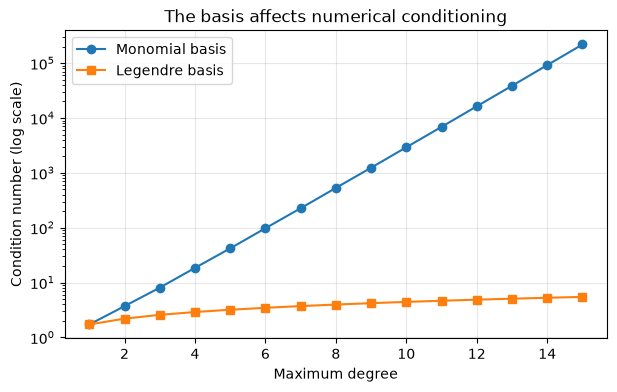

In [10]:
# Conditioning comparison on [-1, 1].
x_cond = np.linspace(-1, 1, 100)
max_degrees = np.arange(1, 16)
monomial_conditions = []
legendre_conditions = []

for d in max_degrees:
    V_mono = np.vander(x_cond, N=d + 1, increasing=True)
    V_leg = np.polynomial.legendre.legvander(x_cond, d)
    monomial_conditions.append(np.linalg.cond(V_mono))
    legendre_conditions.append(np.linalg.cond(V_leg))

plt.figure(figsize=(7, 4))
plt.semilogy(max_degrees, monomial_conditions, marker='o', label='Monomial basis')
plt.semilogy(max_degrees, legendre_conditions, marker='s', label='Legendre basis')
plt.xlabel('Maximum degree')
plt.ylabel('Condition number (log scale)')
plt.title('The basis affects numerical conditioning')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Bias, variance, and polynomial degree

We now fit polynomials of increasing degree to noisy observations from

$$
f(x)=\sin(2\pi x).
$$

Expected pattern:

- low degree: high bias and underfitting;
- moderate degree: useful trade-off;
- very high degree: low training error but unstable test behavior.

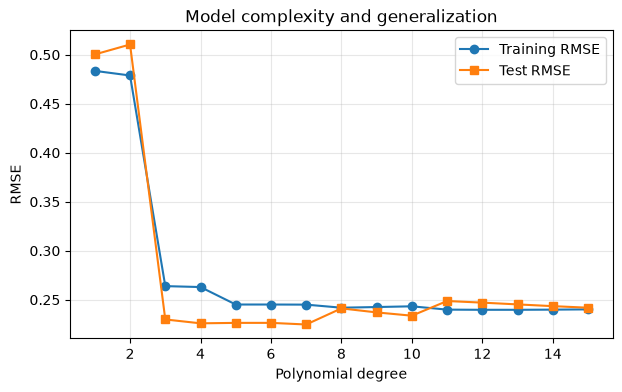

In [11]:
# Generate noisy data.
n = 70
X = rng.uniform(0, 1, size=(n, 1))
y_true = np.sin(2 * np.pi * X[:, 0])
y = y_true + rng.normal(0, 0.25, size=n)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

degrees = range(1, 16)
train_rmse, test_rmse = [], []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)
    test_rmse.append(mean_squared_error(y_test, model.predict(X_test)) ** 0.5)

plt.figure(figsize=(7, 4))
plt.plot(list(degrees), train_rmse, marker='o', label='Training RMSE')
plt.plot(list(degrees), test_rmse, marker='s', label='Test RMSE')
plt.xlabel('Polynomial degree')
plt.ylabel('RMSE')
plt.title('Model complexity and generalization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

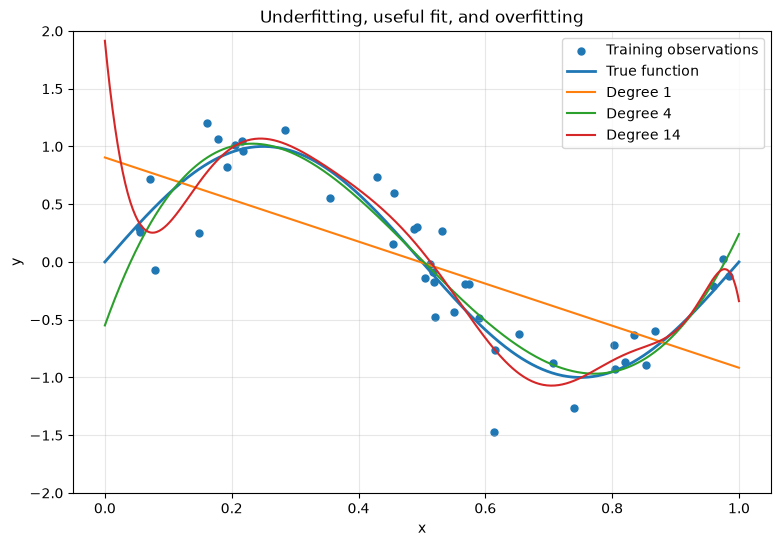

In [17]:
# Visualize representative fits.
x_grid = np.linspace(0, 1, 500).reshape(-1, 1)

plt.figure(figsize=(9, 6))
plt.scatter(X_train[:, 0], y_train, s=25, label='Training observations')
plt.plot(x_grid[:, 0], np.sin(2 * np.pi * x_grid[:, 0]), linewidth=2, label='True function')

for d in [1, 4, 14]:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X_train, y_train)
    plt.plot(x_grid[:, 0], model.predict(x_grid), label=f'Degree {d}')

plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Underfitting, useful fit, and overfitting')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Regularization and generalizability

Ridge regression minimizes

$$
\|y-\Phi\beta\|_2^2+\lambda\|\beta\|_2^2.
$$

Regularization does not merely make coefficients small. It changes the learning rule's preference among functions, often reducing variance and improving generalization.

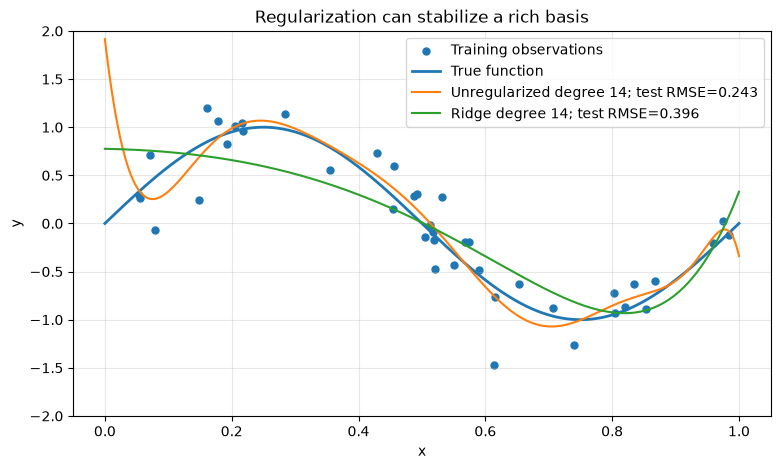

In [19]:
# High-degree polynomial with and without ridge regularization.
models = {
    'Unregularized degree 14': make_pipeline(PolynomialFeatures(14), LinearRegression()),
    'Ridge degree 14': make_pipeline(PolynomialFeatures(14), StandardScaler(), Ridge(alpha=1.0)),
}

plt.figure(figsize=(9, 5))
plt.scatter(X_train[:, 0], y_train, s=25, label='Training observations')
plt.plot(x_grid[:, 0], np.sin(2 * np.pi * x_grid[:, 0]), linewidth=2, label='True function')

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(x_grid)
    rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5
    plt.plot(x_grid[:, 0], pred, label=f'{name}; test RMSE={rmse:.3f}')

plt.ylim(-2, 2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regularization can stabilize a rich basis')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. What “generalizable” should mean operationally

A model is not proven generalizable merely because one test score is good. Ask:

1. Was the test set untouched during model selection?
2. Does the split match deployment conditions?
3. Are observations independent enough for the chosen split?
4. Is there temporal, group, or preprocessing leakage?
5. Are uncertainty and variability reported?
6. Does performance remain acceptable under reasonable distribution changes?

Learning theory gives idealized guarantees under assumptions. Applied validation checks whether those assumptions are plausible enough for the real problem.

## Exercises

1. Derive the complete degree-3 polynomial basis for three variables and verify its size using $\binom{p+d}{d}$.
2. Replace the sinusoidal target with a cubic target. How does the best degree change?
3. Repeat the experiment with 20, 70, and 500 training points. Compare the test-error curves.
4. Compare monomial, Legendre, and Chebyshev design-matrix condition numbers.
5. Explain in your own words why “training error is small” does not imply PAC-style success.
6. Give one example of a class that is expressive enough but difficult to optimize, and one class that is easy to optimize but too restrictive.

## Key takeaways

- Learning requires a representation, an objective, data, and an algorithm.
- PAC learning formalizes accuracy and confidence as functions of sample size and class complexity.
- Generalization is about population behavior, not memorizing the sample.
- Polynomial regression is a linear model over a nonlinear basis.
- A complete basis includes all monomials up to the chosen total degree.
- Function-space language makes feature engineering and approximation more precise.
- More capacity can reduce approximation error while increasing estimation and numerical problems.